# 📧 Email Spam Classification using NLP

## Business Problem

Email spam is one of the most common cybersecurity challenges faced by individuals and organizations. Spam emails waste user's time, consume storage resources, and often contain phishing attempts or malicious links.

The objective of this project is to build a machine learning model that automatically classifies emails as **Spam** or **Not Spam** using Natural Language Processing (NLP) techniques.

This project demonstrates an end-to-end machine learning workflow including data preprocessing, feature engineering, model training, evaluation, and deployment using FastAPI and Streamlit.

## Dataset Information

The dataset contains labeled email messages belonging to two classes:

- Spam
- Ham (Not Spam)

Each record contains:

- Email Text
- Label

Goal:

Predict whether a new email belongs to the Spam or Not Spam category.

In [40]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Natural Language Processing
import nltk
import string

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

from collections import Counter

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

In [2]:
df=pd.read_csv(r"C:\Users\Admin\Desktop\Shrawani\Projects\Email_Spam_Classifier\data\spam.tsv",sep='\t')

In [3]:
df.head()

,label,message,length,punct
0,ham,"Go until jurong point, crazy.. Available only ...",111,9
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,6
3,ham,U dun say so early hor... U c already then say...,49,6
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,2


## Dataset Overview

In [4]:
df.shape

(5572, 4)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
 2   length   5572 non-null   int64 
 3   punct    5572 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 174.3+ KB


In [6]:
df.describe()

,length,punct
count,5572.000000,5572.000000
mean,80.489950,4.177495
std,59.942907,4.623919
min,2.000000,0.000000
25%,36.000000,2.000000
50%,62.000000,3.000000
75%,122.000000,6.000000
max,910.000000,133.000000


### Data Quality Checks

In [7]:
print("Number of missing values in each column:")
df.isnull().sum()

Number of missing values in each column:


label      0
message    0
length     0
punct      0
dtype: int64

#### Observation:

- The dataset contains no missing values.
- Since all columns are complete, no imputation or removal of missing records was required.
- The dataset is suitable for further preprocessing and model development.

In [8]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 403


In [9]:
df = df.drop_duplicates()

In [10]:
print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (5169, 4)


In [11]:
df.duplicated().sum()

np.int64(0)

#### Observation

- The dataset initially contained 403 duplicate records.
- Duplicate entries were removed to improve data quality and prevent the model from learning repeated samples.
- After removing duplicates, the dataset contained 5,169 unique email records.

## Exploratory Data Analysis

### Class Distribution

In [12]:
class_distribution=df["label"].value_counts()
print(class_distribution)

print("\nPercentage Distribution:")
print((class_distribution / len(df) * 100).round(2))

label
ham     4516
spam     653
Name: count, dtype: int64

Percentage Distribution:
label
ham     87.37
spam    12.63
Name: count, dtype: float64


#### Observation

- The majority of email messages belong to the **ham** class, while the **spam** class represents a much smaller portion of the dataset.
- This indicates a **class imbalance**, which is common in real-world spam detection datasets.
- During model evaluation, special attention will be given to **precision**, **recall**, and **F1-score** to ensure the model performs well on the minority (spam) class.

### Message Length Analysis

In [13]:
df.groupby("label")["length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4516.0,70.905890,56.715046,2.0,34.0,53.0,91.0,910.0
spam,653.0,137.704441,29.821348,13.0,132.0,148.0,157.0,223.0


#### Observation

- Ham messages have an average length of approximately **71 characters**, whereas spam messages average around **138 characters**.
- This indicates that spam messages are generally longer than legitimate messages, likely due to promotional content, advertisements, or phishing attempts.
- Ham messages exhibit greater variability in length, while spam messages are more consistent in size.
- Message length appears to be a potentially useful feature for distinguishing spam from ham emails.

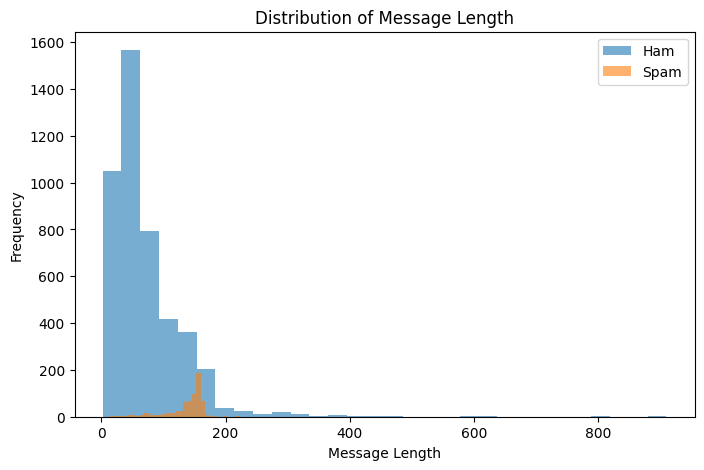

In [14]:
plt.figure(figsize=(8,5))
plt.hist(df[df["label"]=="ham"]["length"], bins=30, alpha=0.6, label="Ham")
plt.hist(df[df["label"]=="spam"]["length"], bins=30, alpha=0.6, label="Spam")
plt.legend()
plt.xlabel("Message Length")
plt.ylabel("Frequency")
plt.title("Distribution of Message Length")
plt.show()

#### Observation

- The histogram shows that ham messages are generally shorter, whereas spam messages tend to contain more characters.
- Spam messages are concentrated around higher message lengths, indicating that promotional or phishing content is typically longer than legitimate messages.
- Although there is some overlap between the two classes, message length provides useful discriminatory information and can be considered an informative feature during exploratory data analysis.
- Since both classes overlap in certain length ranges, message length alone is insufficient for classification. Therefore, Natural Language Processing techniques such as TF-IDF will be used to capture the textual content of the messages for accurate prediction.

### Punctuation Analysis

In [15]:
df.groupby("label")["punct"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4516.0,3.830159,4.488122,0.0,1.0,3.0,5.0,133.0
spam,653.0,5.643185,3.500627,0.0,3.0,5.0,8.0,26.0


#### Observation

- Spam messages contain a higher average number of punctuation marks (5.64) compared to ham messages (3.83).
- This suggests that spam messages often use excessive punctuation to attract the reader's attention or create a sense of urgency.
- Ham messages show greater variability in punctuation usage, indicating more diverse writing styles.
- Although punctuation count provides useful information, it is not sufficient on its own to distinguish spam from ham messages. It should be considered as a supporting feature alongside textual features extracted using NLP techniques.

## Data Preparation

In this phase, the text data is cleaned and transformed into a format suitable for machine learning. The preprocessing pipeline removes unnecessary information while preserving meaningful textual features that can improve classification performance.

In [16]:
# Download nltk resources

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### Create Stemmer

In [17]:
ps = PorterStemmer()

### Create the Preprocessing Function

In [18]:
def transform_text(text):

    # Convert to lowercase
    text = text.lower()

    # Tokenize the text
    text = nltk.word_tokenize(text)

    words = []

    # Keep only alphanumeric tokens
    for word in text:
        if word.isalnum():
            words.append(word)

    filtered_words = []

    # Remove stopwords
    for word in words:
        if word not in stopwords.words("english"):
            filtered_words.append(word)

    stemmed_words = []

    # Apply stemming
    for word in filtered_words:
        stemmed_words.append(ps.stem(word))

    return " ".join(stemmed_words)

### Function Test

In [19]:
sample = "Congratulations!! You have won a FREE iPhone. Click here now!!"

print(transform_text(sample))

congratul free iphon click


### NLP Preprocessing Pipeline

The preprocessing function performs the following operations:

1. Converts all text to lowercase.
2. Splits the sentence into individual words (tokenization).
3. Removes non-alphanumeric characters.
4. Removes common English stopwords such as *the*, *is*, and *and*.
5. Applies Porter Stemming to reduce words to their root form.
6. Returns the cleaned text for feature extraction.

## Feature Engineering

In this phase, the cleaned text generated during preprocessing is transformed into meaningful features for machine learning. 
Before vectorization, the cleaned text is analyzed to identify the most frequent words in spam and ham messages.
This provides insights into the vocabulary used by each class.

### Apply the preprocessing function

In [43]:
df["transformed_text"] = df["message"].apply(transform_text)

In [44]:
df[["message", "transformed_text"]].head()

,message,transformed_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


#### Observation

A new column named **transformed_text** was created to store the cleaned version of each email message. Keeping the original and 
transformed text separately preserves the raw data while allowing the machine learning model to use the processed text for feature extraction.

### Word Count Analysis

In [45]:
# most frequent words in spam

In [46]:
spam_words = []

for message in df[df["label"] == 1]["transformed_text"]:
    spam_words.extend(message.split())

Counter(spam_words).most_common(30)

[('call', 320),
 ('free', 191),
 ('2', 155),
 ('txt', 141),
 ('text', 122),
 ('u', 120),
 ('ur', 119),
 ('mobil', 114),
 ('stop', 108),
 ('repli', 103),
 ('claim', 98),
 ('4', 97),
 ('prize', 82),
 ('get', 74),
 ('new', 64),
 ('servic', 64),
 ('tone', 63),
 ('send', 61),
 ('urgent', 58),
 ('nokia', 57),
 ('contact', 56),
 ('award', 55),
 ('phone', 52),
 ('cash', 51),
 ('pleas', 51),
 ('week', 49),
 ('win', 48),
 ('c', 45),
 ('collect', 45),
 ('min', 45)]

#### Observation

The most frequent words in spam messages include promotional terms such as **free**, **win**, **call**, **claim**, and **prize**. These words are strong indicators of spam and help the machine learning model distinguish spam from legitimate messages.

### Most frequent words in ham

In [47]:
ham_words = []

for message in df[df["label"] == 0]["transformed_text"]:
    ham_words.extend(message.split())

Counter(ham_words).most_common(30)

[('u', 897),
 ('go', 407),
 ('get', 351),
 ('2', 288),
 ('gt', 288),
 ('lt', 287),
 ('come', 278),
 ('got', 239),
 ('know', 237),
 ('like', 236),
 ('call', 235),
 ('love', 222),
 ('time', 220),
 ('ok', 218),
 ('good', 215),
 ('want', 209),
 ('ur', 203),
 ('day', 195),
 ('ü', 173),
 ('need', 171),
 ('one', 166),
 ('4', 162),
 ('lor', 159),
 ('home', 152),
 ('think', 150),
 ('see', 148),
 ('take', 144),
 ('still', 144),
 ('da', 142),
 ('tell', 133)]

#### Observation

The most common words in ham messages are everyday conversational words related to personal communication. This reflects the
natural language used in legitimate text messages.

### WordCloud

In [48]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


### Spam WordCloud

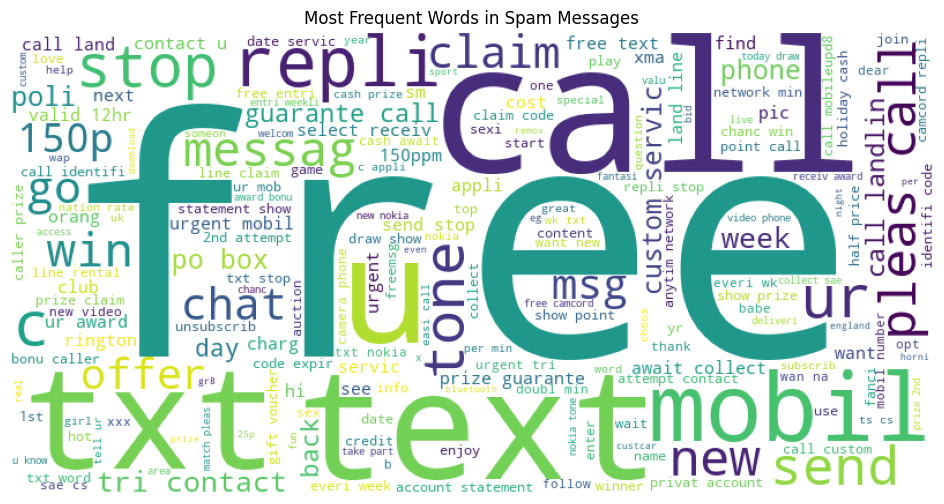

In [49]:
spam_wc = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(" ".join(spam_words))

plt.figure(figsize=(12,6))
plt.imshow(spam_wc)
plt.axis("off")
plt.title("Most Frequent Words in Spam Messages")
plt.show()

#### Observation

The WordCloud highlights the most frequently occurring words in spam messages after text preprocessing. Words such as **free**, 
**text**, **call**, **reply**, **claim**, **win**, and **offer** appear prominently, indicating that spam messages are largely 
promotional and action-oriented. The visualization also confirms that the preprocessing pipeline has successfully removed common stopwords 
and reduced words to their root forms using stemming. These distinctive terms are expected to contribute significantly to the machine learning model 
during feature extraction using TF-IDF.

### Ham WordCloud

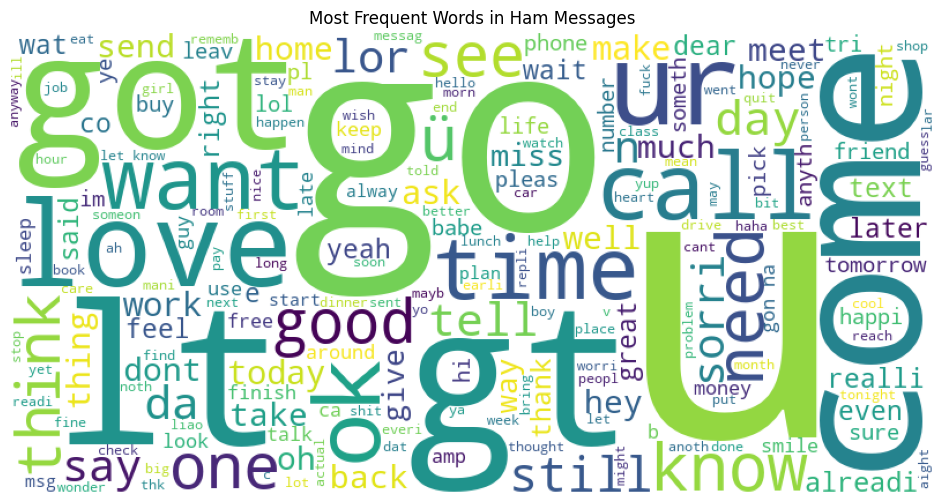

In [59]:
ham_wc = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(" ".join(ham_words))

plt.figure(figsize=(12,6))
plt.imshow(ham_wc)
plt.axis("off")
plt.title("Most Frequent Words in Ham Messages")
plt.show()

#### Observation

The WordCloud for ham messages highlights commonly used conversational words such as **go**, **come**, **love**, **know**, **good**, and **time**. These words reflect everyday personal communication and differ significantly from the promotional vocabulary observed in spam messages. The visualization confirms that the preprocessing pipeline has effectively cleaned the text while preserving meaningful words that will be used for feature extraction.

In [50]:
# Convert labels to numeric

In [51]:
df["label"]=df["label"].map({"ham":0,"spam":1})

In [52]:
X=df["message"]
y=df["label"]

In [53]:
# This is highly imbalanced data, we need to apply data balancing techniques after train test split

In [54]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [55]:
tfidf = TfidfVectorizer(stop_words='english')

In [56]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf=tfidf.transform(X_test)


In [57]:
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

ValueError: Input y contains NaN.

In [ ]:
y_pred = model.predict(X_test_tfidf)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

In [ ]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

In [ ]:
# model saving

In [ ]:
joblib.dump(model, "spam_model.pkl")
joblib.dump(tfidf, "tfidf.pkl")

In [ ]:
def predict_email(text):
    tfidf_test = tfidf.transform([text])
    prediction = model.predict(tfidf_test)[0]
    
    return "Spam" if prediction == 1 else "Not Spam"

# Example
print(predict_email("Congratulations! You’ve won a $500 gift card! Click here to claim your prize"))
print(predict_email("Let's meet tomorrow at 10am"))